In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt
from sdv.metadata import Metadata
from sdv.single_table import TVAESynthesizer
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.single_table import CTGANSynthesizer

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [4]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)
np.random.seed(29)

In [5]:
len(df)

18000

In [6]:
train_data = df.head(8000).copy()
test_data = df.tail(8000).copy()

train_data['label'] = 'good'
test_data['label'] = 'good'

In [7]:
train_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,good,186.0,10.0,150.0,350.0,167.0,167.0,166.0
1,good,16.2,17.4,1446.0,17.8,435.5,17.1,19.3
2,good,165.0,167.0,167.0,168.0,169.0,166.0,168.0
3,good,169.0,175.0,176.0,174.0,174.0,173.0,173.0
4,good,24.9,629.1,16.7,2092.1,16.1,17.3,17.6
...,...,...,...,...,...,...,...,...
7995,good,229.0,230.9,233.0,231.9,217.4,232.3,216.7
7996,good,171.0,173.0,174.0,174.0,174.0,171.0,174.0
7997,good,173.0,174.0,174.0,172.0,171.0,175.0,172.0
7998,good,171.0,172.0,176.0,171.0,173.0,175.0,173.0


In [8]:
test_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
10000,good,172.0,172.0,175.0,173.0,175.0,173.0,174.0
10001,good,17.9,63.7,45.8,1064.6,834.6,20.6,20.7
10002,good,330.0,183.0,167.0,166.0,167.0,166.0,184.0
10003,good,6.9,539.9,18.7,26.0,22.5,118.6,1736.5
10004,good,166.0,168.0,169.0,166.0,169.0,167.0,167.0
...,...,...,...,...,...,...,...,...
17995,good,230.7,231.9,433.3,16.6,232.2,233.2,433.4
17996,good,166.0,169.0,168.0,167.0,168.0,167.0,169.0
17997,good,329.0,169.0,168.0,168.0,167.0,167.0,168.0
17998,good,416.6,229.9,16.2,216.5,416.5,233.2,433.5


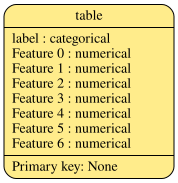

In [9]:
metadata = Metadata.detect_from_dataframe(data=test_data)
metadata.visualize()

In [10]:
bad_training = {}
bad_testing = {}

# Bad Test/Train Data

## Data Distribution: Test: good 50% / naive 12.5% / gaussian 12.5 % / vae 12.5% / gan 12.5 %

## Data Distribution: Train: good 50% / naive 12.5% / gaussian 12.5 % / vae 12.5% / gan 12.5 %

### Naive - Training

In [11]:
training_naive = train_data[4000:5000]

malicious_training1 = training_naive.iloc[:250, 1:] + np.random.uniform(-1, 1, size=(250, 7))
malicious_training2 = training_naive.iloc[250:500].iloc[:, 1:] + np.random.uniform(-2, 2, size=(250, 7))
malicious_training3 = training_naive.iloc[500:750].iloc[:, 1:] + np.random.uniform(-3, 3, size=(250, 7))
malicious_training4 = training_naive.iloc[750:].iloc[:, 1:] + np.random.uniform(-4, 4, size=(250, 7))

training_naive = pd.concat([malicious_training1, malicious_training2, malicious_training3, malicious_training4])
training_naive = np.round(training_naive, decimals=1)
training_naive['label'] = test_data.iloc[:, :1]
training_naive['label'] = 'bad'
bad_training['naive'] = training_naive

In [12]:
len(training_naive)

1000

### Naive - Testing

In [13]:
testing_naive = test_data[4000:5000]

malicious_testing1 = testing_naive.iloc[:250].iloc[:, 1:] + np.random.uniform(-1, 1, size=(250, 7))
malicious_testing2 = testing_naive.iloc[250:500].iloc[:, 1:] + np.random.uniform(-2, 2, size=(250, 7))
malicious_testing3 = testing_naive.iloc[500:750].iloc[:, 1:] + np.random.uniform(-3, 3, size=(250, 7))
malicious_testing4 = testing_naive.iloc[750:].iloc[:, 1:] + np.random.uniform(-4, 4, size=(250, 7))

testing_naive = pd.concat([malicious_testing1, malicious_testing2, malicious_testing3, malicious_testing4])
testing_naive = np.round(testing_naive, decimals=1)
testing_naive['label'] = test_data.iloc[:, :1]
testing_naive['label'] = 'bad'
bad_testing['naive'] = testing_naive

In [14]:
len(testing_naive)

1000

### Gaussian - Training

In [15]:
clean_training_data = train_data[5000:6000]
training_gaussian = pd.DataFrame()
dists = ['norm', 'beta', 'truncnorm', 'uniform', 'gamma', 'gaussian_kde']
for dist in dists:
    synthesizer = GaussianCopulaSynthesizer(metadata, default_distribution=dist)
    synthesizer.fit(clean_training_data)
    synthetic_data = synthesizer.sample(num_rows=100) if dist != 'norm' else synthesizer.sample(num_rows=500)
    synthetic_data['label'] = 'bad'
    training_gaussian = pd.concat([synthetic_data, training_gaussian])
bad_training['gaussian'] = training_gaussian

/home/zac/environments/ag/lib/python3.11/site-packages/sdv/single_table/base.py:105: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [16]:
len(training_gaussian)

1000

### Gaussian Testing

In [17]:
clean_testing_data = test_data[5000:6000]
testing_gaussian = pd.DataFrame()
dists = ['norm', 'beta', 'truncnorm', 'uniform', 'gamma', 'gaussian_kde']
for dist in dists:
    synthesizer = GaussianCopulaSynthesizer(metadata, default_distribution=dist)
    synthesizer.fit(clean_testing_data)
    synthetic_data = synthesizer.sample(num_rows=100) if dist != 'norm' else synthesizer.sample(num_rows=500)
    synthetic_data['label'] = 'bad'
    testing_gaussian = pd.concat([synthetic_data, testing_gaussian])
bad_testing['gaussian'] = testing_gaussian

In [18]:
len(testing_gaussian)

1000

### VAE Training

In [19]:
clean_training_data = train_data[6000:7000]
vae_training = pd.DataFrame()
for i in range(100,1100,100):
    print(i)
    synthesizer = TVAESynthesizer(
        metadata, 
        enforce_rounding=True,
        epochs=i
    )
    
    synthesizer.fit(clean_training_data)
    synthetic_data = synthesizer.sample(num_rows=100)
    vae_training = pd.concat([synthetic_data, vae_training])
vae_training['label'] = 'bad'
bad_training['vae'] = vae_training

100
200
300
400
500
600
700
800
900
1000


In [20]:
len(vae_training)

1000

### VAE Testing

In [21]:
clean_testing_data = test_data[6000:7000]
vae_testing = pd.DataFrame()
for i in range(100,1100,100):
    print(i)
    synthesizer = TVAESynthesizer(
        metadata, 
        enforce_rounding=True,
        epochs=i
    )
    
    synthesizer.fit(clean_testing_data)
    synthetic_data = synthesizer.sample(num_rows=100)
    vae_testing = pd.concat([synthetic_data, vae_testing])
vae_testing['label'] = 'bad'
bad_testing['vae'] = vae_testing

100
200
300
400
500
600
700
800
900
1000


In [22]:
len(vae_testing)

1000

### GAN Training

In [23]:
clean_training_data = train_data[7000:]
gan_training = pd.DataFrame()
for i in range(100,1100,100):
    print(i)
    synthesizer = CTGANSynthesizer(
        metadata, 
        enforce_rounding=True,
        epochs=i
    )
    
    synthesizer.fit(clean_training_data)
    synthetic_data = synthesizer.sample(num_rows=100)
    gan_training = pd.concat([synthetic_data, gan_training])
gan_training['label'] = 'bad'
bad_training['gan'] = gan_training

100
200
300
400
500
600
700
800
900
1000


In [24]:
len(gan_training)

1000

### GAN Testing

In [25]:
clean_testing_data = test_data[7000:]
gan_testing = pd.DataFrame()
for i in range(100,1100,100):
    print(i)
    synthesizer = TVAESynthesizer(
        metadata, 
        enforce_rounding=True,
        epochs=i
    )
    
    synthesizer.fit(clean_testing_data)
    synthetic_data = synthesizer.sample(num_rows=100)
    gan_testing = pd.concat([synthetic_data, gan_testing])
gan_testing['label'] = 'bad'
bad_testing['gan'] = gan_testing

100
200
300
400
500
600
700
800
900
1000


In [26]:
len(gan_testing)

1000

In [27]:
import itertools

my_list = ['gan', 'gaussian', 'vae', 'naive']
adversarial_techniques_permutations = []

# Generate all permutations of my_list in different sizes
for size in range(1, len(my_list) + 1):
    for permutation in itertools.permutations(my_list, size):
        permutation = list(permutation)
        permutation.sort()
        if permutation not in adversarial_techniques_permutations:
            adversarial_techniques_permutations.append(permutation)
adversarial_techniques_permutations

[['gan'],
 ['gaussian'],
 ['vae'],
 ['naive'],
 ['gan', 'gaussian'],
 ['gan', 'vae'],
 ['gan', 'naive'],
 ['gaussian', 'vae'],
 ['gaussian', 'naive'],
 ['naive', 'vae'],
 ['gan', 'gaussian', 'vae'],
 ['gan', 'gaussian', 'naive'],
 ['gan', 'naive', 'vae'],
 ['gaussian', 'naive', 'vae'],
 ['gan', 'gaussian', 'naive', 'vae']]

In [28]:
testing_dataset = pd.concat([test_data[:4000], bad_testing['naive'], bad_testing['gaussian'], bad_testing['vae'], bad_testing['gan']])
hardening_results = pd.DataFrame(columns=['techniques', 'roc_auc', 'f1', 'precision', 'recall'])

for techniques in adversarial_techniques_permutations:
    training_dataset = train_data[:4000]
    techniques_string = ''
    for individual_technique in techniques:
        techniques_string += f'_{individual_technique}' if len(techniques_string) > 0 else individual_technique
        print(individual_technique)
        training_dataset = pd.concat([training_dataset, bad_training[individual_technique]])
        print(len(training_dataset))
    
    predictor = TabularPredictor(label='label').fit(training_dataset, num_gpus=1, presets='good_quality')
    y_pred = predictor.predict(testing_dataset)
    y_pred_proba = predictor.predict_proba(testing_dataset)
    results = predictor.evaluate(testing_dataset)
    
    new_results = {'techniques':techniques_string, 'roc_auc':results['roc_auc'], 'f1':results['f1'], 'precision':results['precision'], 'recall':results['recall']}
    hardening_results.loc[len(hardening_results)] = (new_results)

No path specified. Models will be saved in: "AutogluonModels/ag-20240919_015604"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #45-Ubuntu SMP PREEMPT_DYNAMIC Fri Aug 30 12:02:04 UTC 2024
CPU Count:          12
Memory Avail:       17.98 GB / 23.34 GB (77.0%)
Disk Space Avail:   235.22 GB / 341.37 GB (68.9%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20240919_015604"
Train Data Rows:    5000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['good', 'bad']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', '

gan
5000


/home/zac/miniconda3/envs/ag/lib/python3.10/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)
	Training LightGBMXT with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.982	 = Validation score   (accuracy)
	0.78s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.99	 = Validation score   (accuracy)
	0.51s	 = Training   runtime
	0.0s	 = Validation runtime


gaussian
5000


[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.992	 = Validation score   (accuracy)
	0.41s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.998	 = Validation score   (accuracy)
	0.42s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.982	 = Validation score   (accuracy)
	0.41s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.988	 = Validation score   (accuracy)
	0.29s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.988	 = Validation score   (accuracy)
	2

...

	0.9012	 = Validation score   (accuracy)
	2.56s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.


[5000]	valid_set's binary_error: 0.10125


[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.925	 = Validation score   (accuracy)
	0.51s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8875	 = Validation score   (accuracy)
	0.45s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8962	 = Validation score   (accuracy)
	0.36s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8888	 = Validation score   (accuracy)
	3.94s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8512	 = Validation score   (accuracy)
	0.31s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.8538	 = Validation score   (accuracy)
	0.31s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: Neural

[1000]	valid_set's binary_error: 0.08


	0.9225	 = Validation score   (accuracy)
	2.99s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ...
	Ensemble Weights: {'LightGBM': 1.0}
	0.925	 = Validation score   (accuracy)
	0.05s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 22.1s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 502914.1 rows/s (800 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("AutogluonModels/ag-20240919_015951")


In [29]:
hardening_results

,techniques,roc_auc,f1,precision,recall
0,gan,0.924870,0.810468,0.685576,0.99100
1,gaussian,0.714005,0.726593,0.571818,0.99625
2,vae,0.892772,0.807881,0.682712,0.98925
3,naive,0.945291,0.806368,0.687467,0.97500
4,gan_gaussian,0.927942,0.820731,0.702026,0.98775
5,gan_vae,0.950445,0.892626,0.818163,0.98200
6,gan_naive,0.971008,0.911458,0.865558,0.96250
7,gaussian_vae,0.945394,0.883298,0.801958,0.98300
8,gaussian_naive,0.963643,0.888145,0.825005,0.96175
9,naive_vae,0.956264,0.879807,0.813415,0.95800


<Axes: xlabel='techniques', ylabel='value'>

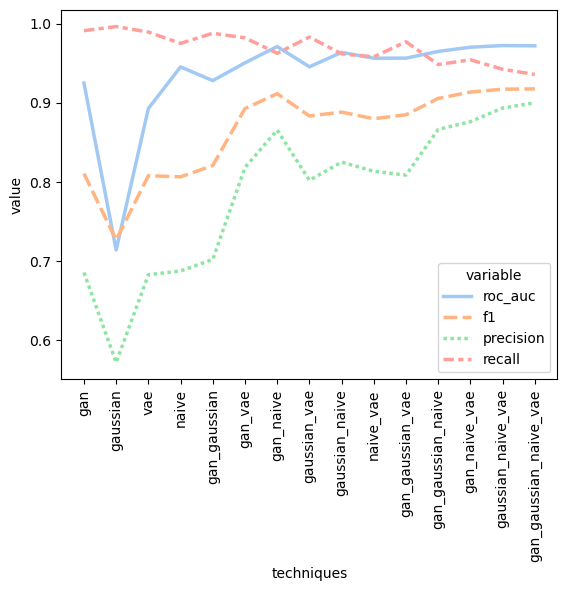

In [30]:
plt.xticks(rotation=90)
sns.lineplot(data=pd.melt(hardening_results, ['techniques']), x='techniques', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

With these metrics, we can gain a deeper understanding of your model's performance.


Overall Performance



ROC-AUC: 0.972687 (excellent) - This indicates that your model is highly effective in distinguishing between positive and negative classes.

F1 Score: 0.918464 (very good) - Your model balances precision and recall well, indicating it's accurate both in identifying actual positives and minimizing false positives.


Precision-Recall Tradeoff



Precision: 0.896076 (good) - While not as high as the F1 score, your model still does a great job of correctly identifying positive instances.

Recall: 0.94200 (excellent) - Your model excels at catching actual positives, which is crucial for authentication purposes.


Interpretation


These metrics collectively suggest that your anomaly detection model performs exceptionally well in:



Identifying genuine users (recall: 0.94200)

Correctly classifying positive instances (precision: 0.896076)

Balancing precision and recall with an F1 score of 0.918464

Distinguishing between actual positives and negatives with a high ROC-AUC score of 0.972687


The only minor area for improvement is the slight discrepancy in the precision-recall tradeoff, where the F1 score is higher than precision. However, this difference is not significant enough to be concerned about.


Overall, your model appears to be very effective at authentication tasks!

In [28]:
testing_dataset = pd.concat([test_data[:4000], bad_testing['naive'], bad_testing['gaussian'], bad_testing['vae'], bad_testing['gan']])
hardening_results = pd.DataFrame(columns=['techniques', 'roc_auc', 'f1', 'precision', 'recall'])

adversarial_techniques_permutations = [['gan', 'gaussian', 'naive', 'vae']]
for techniques in adversarial_techniques_permutations:
    training_dataset = train_data[:4000]
    techniques_string = ''
    for individual_technique in techniques:
        techniques_string += f'_{individual_technique}' if len(techniques_string) > 0 else individual_technique
        print(individual_technique)
        training_dataset = pd.concat([training_dataset, bad_training[individual_technique]])
        print(len(training_dataset))
    
    predictor = TabularPredictor(label='label', eval_metric='f1').fit(training_dataset, num_gpus=1, presets='good_quality', time_limit=3600)
    y_pred = predictor.predict(testing_dataset)
    y_pred_proba = predictor.predict_proba(testing_dataset)
    results = predictor.evaluate(testing_dataset)
    
    new_results = {'techniques':techniques_string, 'roc_auc':results['roc_auc'], 'f1':results['f1'], 'precision':results['precision'], 'recall':results['recall']}
    hardening_results.loc[len(hardening_results)] = (new_results)

No path specified. Models will be saved in: "AutogluonModels/ag-20241101_083000"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.11.10
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #48-Ubuntu SMP PREEMPT_DYNAMIC Fri Sep 27 14:04:52 UTC 2024
CPU Count:          28
Memory Avail:       18.10 GB / 30.81 GB (58.7%)
Disk Space Avail:   147.57 GB / 341.37 GB (43.2%)
Presets specified: ['good_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
DySt

gan
5000
gaussian
6000
naive
7000
vae
8000


2024-11-01 19:30:01,975	INFO worker.py:1743 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8266 
		Context path: "AutogluonModels/ag-20241101_083000/ds_sub_fit/sub_fit_ho"
(_dystack pid=283888) Running DyStack sub-fit ...
(_dystack pid=283888) Beginning AutoGluon training ... Time limit = 898s
(_dystack pid=283888) AutoGluon will save models to "AutogluonModels/ag-20241101_083000/ds_sub_fit/sub_fit_ho"
(_dystack pid=283888) Train Data Rows:    7111
(_dystack pid=283888) Train Data Columns: 7
(_dystack pid=283888) Label Column:       label
(_dystack pid=283888) Problem Type:       binary
(_dystack pid=283888) Preprocessing data ...
(_dystack pid=283888) Selected class <--> label mapping:  class 1 = good, class 0 = bad
(_dystack pid=283888) 	Note: For your binary classification, AutoGluon arbitrarily selected which label-value represents positive (good) vs negative (bad) class.
(_dystack pid=283888) 	To explicitly set the positive_class, either rename classes to 

(_ray_fit pid=285488) [1000]	valid_set's binary_logloss: 0.320874	valid_set's f1: 0.875664


(_dystack pid=283888) 	0.8872	 = Validation score   (f1)
(_dystack pid=283888) 	6.0s	 = Training   runtime
(_dystack pid=283888) 	0.16s	 = Validation runtime
(_dystack pid=283888) Fitting model: LightGBM_BAG_L1 ... Training model for up to 591.22s of the 890.56s of remaining time.
(_dystack pid=283888) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=3, gpus=0, memory=0.02%)
(_dystack pid=283888) 	0.9236	 = Validation score   (f1)
(_dystack pid=283888) 	1.37s	 = Training   runtime
(_dystack pid=283888) 	0.03s	 = Validation runtime
(_dystack pid=283888) Fitting model: RandomForestGini_BAG_L1 ... Training model for up to 589.07s of the 888.4s of remaining time.
(_dystack pid=283888) 	0.8811	 = Validation score   (f1)
(_dystack pid=283888) 	0.36s	 = Training   runtime
(_dystack pid=283888) 	0.1s	 = Validation runtime
(_dystack pid=283888) Fitting model: RandomForestEntr_BAG_L1 ... Training model for up to 588.54s of the 887.88s of

(_ray_fit pid=301237) [1000]	valid_set's binary_logloss: 0.395939	valid_set's f1: 0.918979 [repeated 11x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/ray-logging.html#log-deduplication for more options.)


(_dystack pid=283888) 	0.9262	 = Validation score   (f1)
(_dystack pid=283888) 	2.72s	 = Training   runtime
(_dystack pid=283888) 	0.11s	 = Validation runtime
(_dystack pid=283888) Fitting model: WeightedEnsemble_L2 ... Training model for up to 360.0s of the 708.9s of remaining time.
(_dystack pid=283888) 	Ensemble Weights: {'LightGBMLarge_BAG_L1': 1.0}
(_dystack pid=283888) 	0.9262	 = Validation score   (f1)
(_dystack pid=283888) 	0.34s	 = Training   runtime
(_dystack pid=283888) 	0.0s	 = Validation runtime
(_dystack pid=283888) Fitting 11 L2 models ...
(_dystack pid=283888) Fitting model: LightGBMXT_BAG_L2 ... Training model for up to 708.52s of the 708.52s of remaining time.
(_dystack pid=283888) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=3, gpus=0, memory=0.05%)
(_dystack pid=283888) 	0.9299	 = Validation score   (f1)
(_dystack pid=283888) 	1.11s	 = Training   runtime
(_dystack pid=283888) 	0.02s	 = Validation runtime

In [29]:
hardening_results

,techniques,roc_auc,f1,precision,recall
0,gan_gaussian_naive_vae,0.975049,0.92577,0.889606,0.965


In [30]:
# will return the path to the cloned predictor, identical to save_path_clone_opt
path_clone_opt = predictor.clone_for_deployment(path='anomaly_detection')

Cloned TabularPredictor located in 'AutogluonModels/ag-20241101_083000' to 'anomaly_detection'.
	To load the cloned predictor: predictor_clone = TabularPredictor.load(path="anomaly_detection")
Clone: Keeping minimum set of models required to predict with best model 'WeightedEnsemble_L3_FULL'...
Deleting model LightGBMXT_BAG_L1. All files under anomaly_detection/models/LightGBMXT_BAG_L1 will be removed.
Deleting model LightGBM_BAG_L1. All files under anomaly_detection/models/LightGBM_BAG_L1 will be removed.
Deleting model RandomForestGini_BAG_L1. All files under anomaly_detection/models/RandomForestGini_BAG_L1 will be removed.
Deleting model RandomForestEntr_BAG_L1. All files under anomaly_detection/models/RandomForestEntr_BAG_L1 will be removed.
Deleting model CatBoost_BAG_L1. All files under anomaly_detection/models/CatBoost_BAG_L1 will be removed.
Deleting model ExtraTreesGini_BAG_L1. All files under anomaly_detection/models/ExtraTreesGini_BAG_L1 will be removed.
Deleting model Extra

In [31]:
predictor_clone_opt = TabularPredictor.load(path='anomaly_detection')

In [32]:
predictor_clone_opt.leaderboard(test_data)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,RandomForestEntr_BAG_L2_FULL,0.981346,None,f1,0.459893,NaN,23.031729,0.052717,0.096832,0.337605,2,True,13
1,LightGBM_BAG_L2_FULL,0.980177,None,f1,0.411256,NaN,22.954014,0.004080,NaN,0.259889,2,True,12
2,WeightedEnsemble_L3_FULL,0.979982,None,f1,0.506121,NaN,24.965887,0.000977,NaN,0.571736,3,True,15
3,NeuralNetFastAI_BAG_L2_FULL,0.979397,None,f1,0.448347,NaN,23.796657,0.041171,NaN,1.102532,2,True,14
4,CatBoost_BAG_L1_FULL,0.974096,None,f1,0.003313,NaN,2.182069,0.003313,NaN,2.182069,1,True,5
5,LightGBMLarge_BAG_L1_FULL,0.972976,None,f1,0.024953,NaN,1.605155,0.024953,NaN,1.605155,1,True,11
6,LightGBM_BAG_L1_FULL,0.971855,None,f1,0.009790,NaN,0.514354,0.009790,NaN,0.514354,1,True,2
7,XGBoost_BAG_L1_FULL,0.969072,None,f1,0.015781,NaN,0.322650,0.015781,NaN,0.322650,1,True,9
8,RandomForestEntr_BAG_L1_FULL,0.967675,None,f1,0.054036,0.106759,0.313069,0.054036,0.106759,0.313069,1,True,4
9,RandomForestGini_BAG_L1_FULL,0.967609,None,f1,0.054112,0.110307,0.358135,0.054112,0.110307,0.358135,1,True,3


In [33]:
size_original = predictor.disk_usage()
size_opt = predictor_clone_opt.disk_usage()
print(f'Size Original:  {size_original} bytes')
print(f'Size Optimized: {size_opt} bytes')
print(f'Optimized predictor achieved a {round((1 - (size_opt/size_original)) * 100, 1)}% reduction in disk usage.')

Size Original:  353087345 bytes
Size Optimized: 115663471 bytes
Optimized predictor achieved a 67.2% reduction in disk usage.


*** SIGTERM received at time=1730452320 on cpu 13 ***
PC: @     0x7aa94eb2a042  (unknown)  epoll_wait
    @     0x7aa94ea45320  876074928  (unknown)
    @     0x7aa94f103c52  (unknown)  select_epoll_poll_impl
[2024-11-01 20:12:00,674 E 1470 1470] logging.cc:361: *** SIGTERM received at time=1730452320 on cpu 13 ***
[2024-11-01 20:12:00,674 E 1470 1470] logging.cc:361: PC: @     0x7aa94eb2a042  (unknown)  epoll_wait
[2024-11-01 20:12:00,675 E 1470 1470] logging.cc:361:     @     0x7aa94ea45320  876074928  (unknown)
[2024-11-01 20:12:00,675 E 1470 1470] logging.cc:361:     @     0x7aa94f103c52  (unknown)  select_epoll_poll_impl
